# AG-HYPOPT · Trial 13

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Twelve trials are registered; cell 2 reports `phase = trials` (12/5), so proposals carry expected-improvement (ei) values. **Best = trial_08** (objective 0.1099). Ranking with mu travel = `lr_mu*(1 - mu_anneal/2)`:

- **trial_08 (0.1099, best, 0 div):** `lr_mu=0.1616`, `mu_anneal=0.3475`, `lr_gamma=0.4157`, `gamma_anneal=0.5318` (travel 0.134). mu 76.5%, gamma 23.1%.
- **trial_12 (0.1115, 0 div):** travel 0.128, nearly trial_08's mu knobs with different gamma knobs.
- **trial_09 (0.1126, 0 div):** travel 0.123.
- **trial_01 (0.1127, 0 div):** travel 0.120; gamma 21.5% (best gamma).
- **trial_05 (0.1135, 0 div):** travel 0.088.
- **trial_07 (0.1140, 0 div):** travel 0.097.
- **trial_06 / trial_11 (0.1188, 0 div):** travels 0.082 / 0.159.
- **trials 10 (0.1975), 03 (0.1362), 04 (0.1418), 02 (0.1449):** the diverging runs.

State of play: the mu-travel optimum is at ~0.13, bracketed by trial_09 (0.123 -> 0.1126), trial_08 (0.134 -> 0.1099) and trial_11 (0.159 -> 0.1188). Trial_12 showed that, at that optimum, changing the gamma schedule barely moves the objective (0.1099 -> 0.1115), so the best region is flat to ~0.002. The larger-travel region (0.18-0.40) is systematically worse (trial_02 at 0.264 was 0.1449). Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_13'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (12/5 trials)
ID |     ei | params
 1 | 3.8337 | {"gamma_anneal": 0.3988576262455078, "lr_gamma": 0.4788718502384427, "lr_mu": 0.47350056132080137, "mu_anneal": 0.3477790685463075}
 2 | 3.9074 | {"gamma_anneal": 0.4949442513311903, "lr_gamma": 0.45783546555561444, "lr_mu": 0.22194862341519359, "mu_anneal": 0.34541226151010845}
 3 | 2.7283 | {"gamma_anneal": 0.48428994974989703, "lr_gamma": 0.787851848200825, "lr_mu": 0.1629843081683101, "mu_anneal": 0.3600939353884405}
 4 | 3.3144 | {"gamma_anneal": 0.5390798871300941, "lr_gamma": 0.5033418411517521, "lr_mu": 0.2773630525467696, "mu_anneal": 0.349348839311955}
 5 | 3.9331 | {"gamma_anneal": 0.5106245408141442, "lr_gamma": 0.4290737343739233, "lr_mu": 0.4794418181092603, "mu_anneal": 0.3373262646960228}
 6 | 2.6303 | {"gamma_anneal": 0.4936776484793497, "lr_gamma": 0.624350893635477, "lr_mu": 0.14235121716213525, "mu_anneal": 0.3415080139168717}
 7 | 3.5414 | {"gamma_anneal": 0.48589618355687386, "lr_gamma": 0.4213117339

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (12 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 8: **ei 3.96** — `lr_mu=0.162`, `mu_anneal=0.345` (travel **0.134**), `lr_gamma=0.491`, `gamma_anneal=0.450`.
- candidate 5: ei 3.93 — `lr_mu=0.479`, `mu_anneal=0.337` (travel 0.399, trial_02 direction), `lr_gamma=0.429`.
- candidate 2: ei 3.91 — `lr_mu=0.222`, `mu_anneal=0.345` (travel 0.184), `lr_gamma=0.458`.
- candidate 1: ei 3.83 — `lr_mu=0.474`, `mu_anneal=0.348` (travel 0.391), `lr_gamma=0.479`.
- candidate 7: ei 3.54 — `lr_mu=0.282`, `mu_anneal=0.325` (travel 0.236), `lr_gamma=0.421`.
- candidate 4: ei 3.31 — `lr_mu=0.277`, `mu_anneal=0.349` (travel 0.229), `lr_gamma=0.503`.
- candidate 6: ei 2.63 — `lr_mu=0.142`, `mu_anneal=0.342` (travel 0.118), `lr_gamma=0.624`.

Candidate 8 has the highest ei and is centred exactly on the established optimum: its travel (0.134) equals trial_08's, and its mu knobs (`lr_mu=0.162`, `mu_anneal=0.345`) are essentially identical to trial_08's (`0.162`/`0.348`), with the gamma schedule differing (`lr_gamma=0.491`, `gamma_anneal=0.450` vs `0.416`/`0.532`) — very close to trial_12's near-best `0.477`/`0.480`. So this is another sample at the optimum with a slightly different gamma schedule; given the flat, noisy neighbourhood, the max-ei proposal is the natural pick. The alternatives are weaker on the evidence: candidates 5, 1, 2, 7 and 4 all sit at travel 0.18-0.40, i.e. the systematically worse large-travel region (trial_02 and trial_11 showed it costs objective); candidate 6 is at a similar-good travel (0.118) but with the highest `lr_gamma` (0.624) of the group and lower ei. So candidate 8 is the highest-ei and best-supported choice.

I choose candidate 8 (8 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.4498768055175392, 'lr_gamma': 0.4911584818438782, 'lr_mu': 0.16169528129896782, 'mu_anneal': 0.34456493938741944}
Running  1nW Trans05 ... 

μ 9.39 -> 10.20 | γ 8.5 -> 4.34 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 43.02 | γ 8.5 -> 6.24 | NLL 5.50


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.41 | γ 14.1 -> 14.73 | NLL 3.65


Running 3nW Trans100 ... 

μ 175.71 -> 111.77 | γ 14.1 -> 14.11 | NLL 3.25



Total: 7.9 min


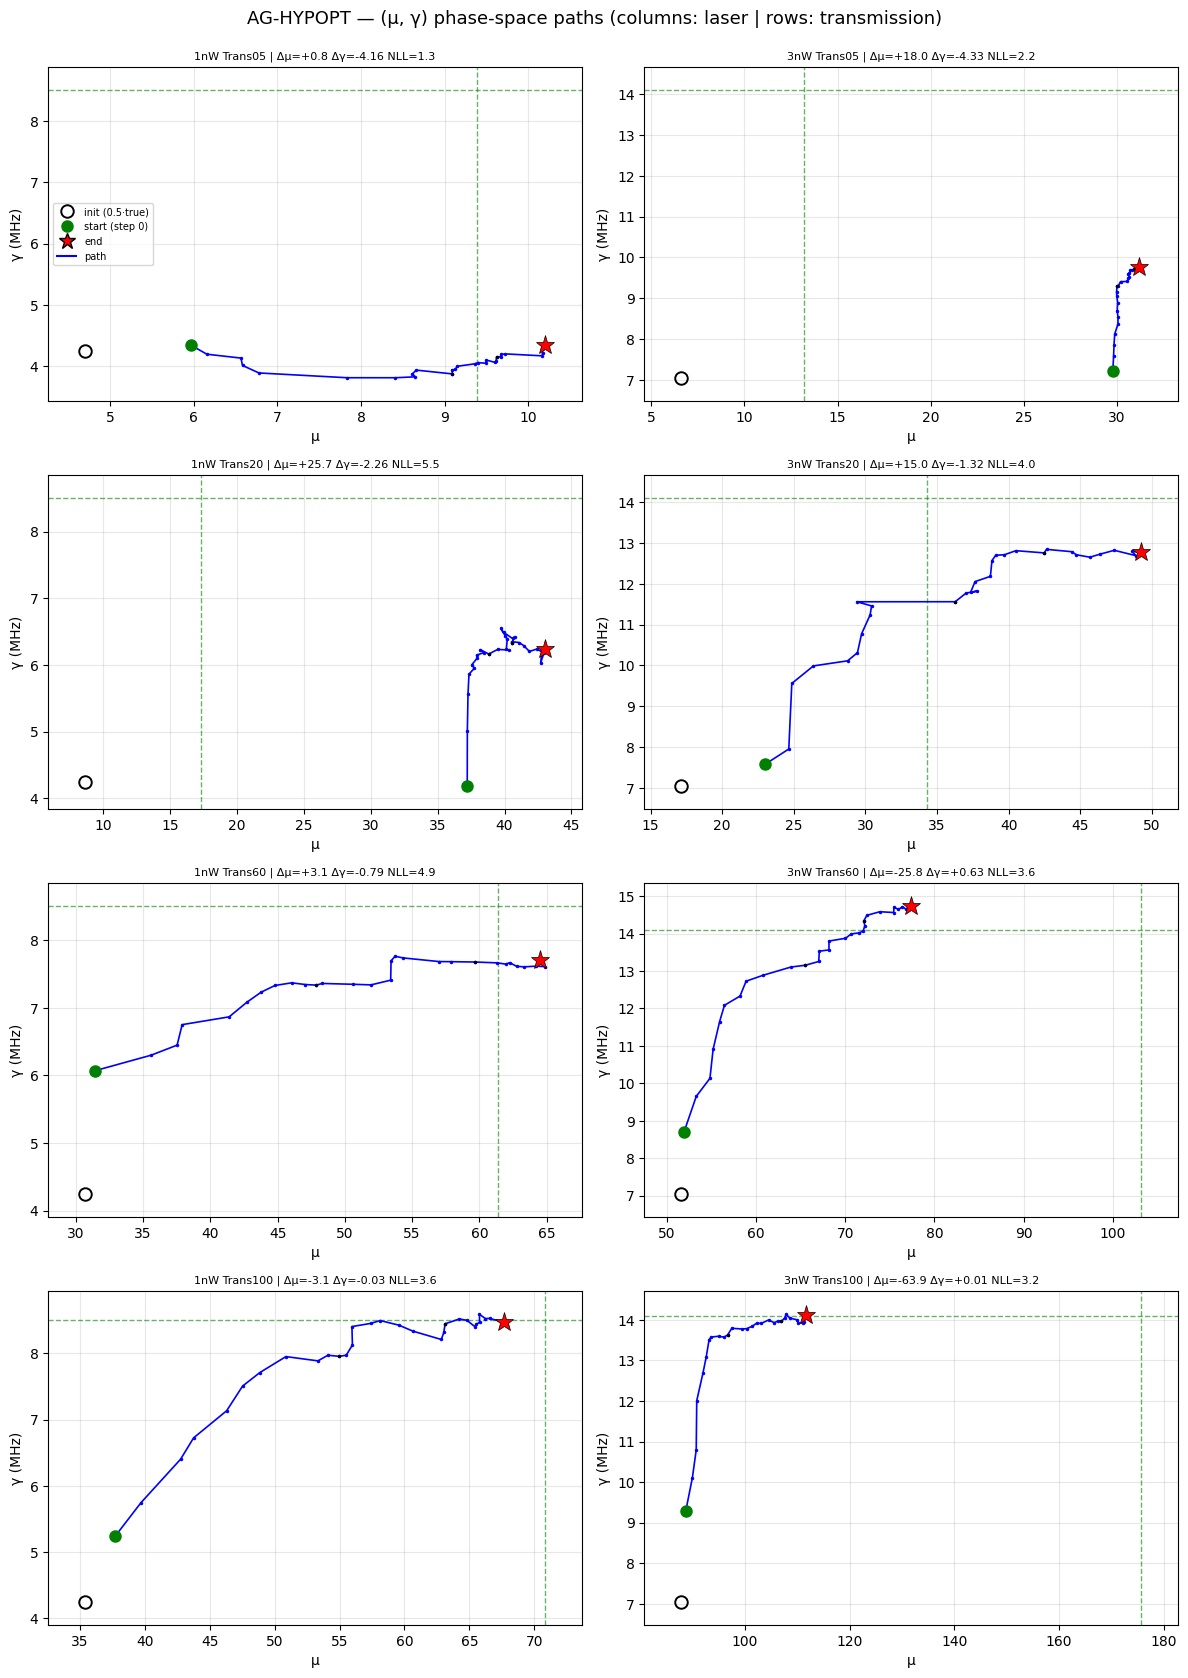

trial finished in 8.0 min
objective = 0.1132 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   10.20    +8.6 |     8.50    4.34   -48.9
1nW Trans20       17.32   43.02  +148.5 |     8.50    6.24   -26.6
1nW Trans60       61.37   64.48    +5.1 |     8.50    7.71    -9.3
1nW Trans100       70.82   67.68    -4.4 |     8.50    8.47    -0.4
3nW Trans05       13.20   31.22  +136.5 |    14.10    9.77   -30.7
3nW Trans20       34.28   49.25   +43.7 |    14.10   12.78    -9.3
3nW Trans60      103.20   77.41   -25.0 |    14.10   14.73    +4.5
3nW Trans100      175.71  111.77   -36.4 |    14.10   14.11    +0.1

weighted objective (T-graded, cap=1.0) = 0.1132 | diverged cells: 0
μ: RMSE 27.347 (rel 74.7%, bias -3.782) | γ: RMSE 2.343 (rel 23.0%, bias -1.532)


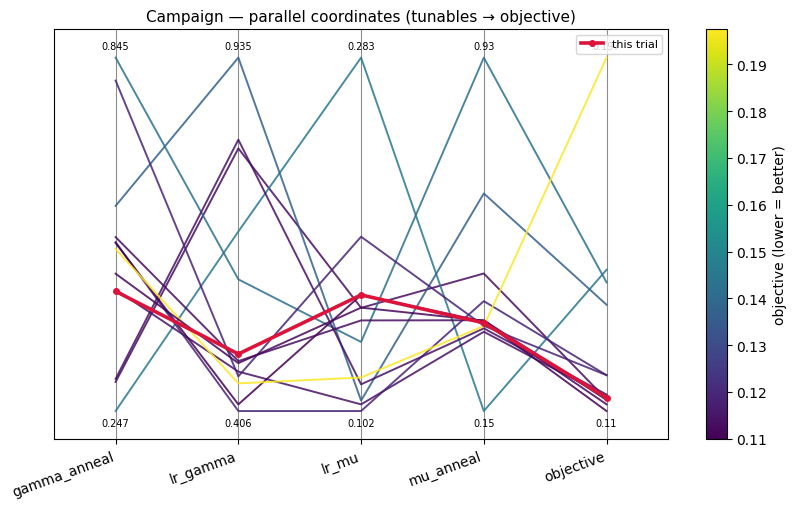

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 13 ran the highest-EI candidate (candidate 8, ei=3.96): `lr_mu=0.1617`, `mu_anneal=0.3446` (effective mu travel 0.134), `lr_gamma=0.4912`, `gamma_anneal=0.4499`. It completed in 8.0 min with objective **0.1132 +/- 0.0825** and **0 diverged cells**. Ranking: trial_08 0.1099 < trial_12 0.1115 < trial_09 0.1126 < trial_01 0.1127 < **trial_13 0.1132** < trial_05 0.1135 < trial_07 0.1140 < ...

Aggregate accuracy: **mu rel-RMSE 74.7%** (RMSE 27.35, bias -3.78); **gamma rel-RMSE 23.0%** (RMSE 2.34, bias -1.53).

Per-cell relative errors:
- **mu:** 1nW T05 +8.6%, T20 +148.5%, T60 +5.1%, T100 -4.4% | 3nW T05 +136.5%, T20 +43.7%, T60 -25.0%, T100 -36.4%.
- **gamma:** 1nW T05 -48.9%, T20 -26.6%, T60 -9.3%, T100 -0.4% | 3nW T05 -30.7%, T20 -9.3%, T60 +4.5%, T100 +0.1%.

Candidate 8 was placed exactly on the known optimum (travel 0.134 = trial_08's; mu knobs nearly identical to trial_08's) with the gamma schedule shifted (`lr_gamma=0.491`, `gamma_anneal=0.450` vs trial_08's `0.416`/`0.532`, and close to trial_12's near-best `0.477`/`0.480`). It landed at 0.1132 — again in the flat optimum band and again not beating trial_08. The 1nW high-T cells were good but not trial_08-good (1nW T60 +5.1%, T100 -4.4%), while the mid-T overshoots stayed large (1nW T20 +148.5%, 3nW T05 +136.5%). The optimum region now has five samples (trials 08, 12, 09, 01, 13) spanning 0.1099-0.1132 with no monotone dependence on any single gamma knob, so the residual ~0.003 spread there is not being reduced by tuning these four parameters.

**Summary:** Trial 13 (lr_mu=0.1617, mu_anneal=0.3446, lr_gamma=0.4912, gamma_anneal=0.4499): objective 0.1132 +/- 0.0825 with 0 diverged cells; a second exact sample at trial_08's mu optimum with a different gamma schedule again failed to beat it (0.1132 vs 0.1099), confirming the optimum region is flat to ~0.003.
**Key insight:** Repeated sampling at the mu optimum (travel 0.13) with varied gamma schedules yields 0.1099-0.1132 with no clean dependence on any knob, so the remaining ~0.003 spread is not tunable with these four parameters - trial_08's exact config remains the best found.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Five near-optimum runs (08, 12, 09, 01, 13) all share the same residual structure and differ only by a few thousandths; the dominant errors (mid/low-T mu overshoot ~+136-149%, 3nW high-T mu undershoot ~-25% to -36%, low-T gamma under-recovery ~-30% to -49%) have not moved since trial_01. This is the strongest evidence yet that the remaining gap is structural, not hyperparameter: the frozen schedule form cannot address the per-regime error pattern; recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 13 (lr_mu=0.1617, mu_anneal=0.3446, lr_gamma=0.4912, gamma_anneal=0.4499): objective 0.1132 +/- 0.0825 with 0 diverged cells; a second exact sample at trial_08's mu optimum with a different gamma schedule again failed to beat it (0.1132 vs 0.1099), confirming the optimum region is flat to ~0.003"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Repeated sampling at the mu optimum (travel 0.13) with varied gamma schedules yields 0.1099-0.1132 with no clean dependence on any knob, so the remaining ~0.003 spread is not tunable with these four parameters - trial_08's exact config remains the best found"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_13 | current best: trial_08


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_14.ipynb. Open it and follow its cells from the top.
